# Part 2: Predictive Modeling - Heart Disease Risk (2026)

Course: Statistics for Data Science (CSE303)
Stage: predictive modeling (extends the exploratory analysis from Part 1)

In Part 1 we explored the Heart Disease Risk 2026 dataset (9000 patients, 27 columns) with descriptive
statistics, distribution plots, categorical analysis, relationships between variables and a full
data-quality check. The data turned out to be clean (no missing values, no duplicates, no impossible
values) and we found clear signals: low max heart rate, high ST depression, older age, high LDL, low
HDL and high blood pressure all go together with heart disease.

This notebook is the modelling part of the project. We build the models required by the assignment:

1. Linear Regression on a numerical feature (a regression task)
2. Logistic Regression on the target variable (a classification task)

We then compare them with a few additional models (k-Nearest Neighbors, Decision Tree, Random Forest,
Naive Bayes) to see whether a different algorithm does better. All models are evaluated on a testing
set that the model has never seen during training.

## Setup: importing the libraries

Same libraries as Part 1 (`pandas`, `numpy`, `matplotlib`, `seaborn`) plus **scikit-learn**, which
gives us the models, the train-test split and the evaluation metrics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score,
                             precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score, roc_curve)

df = pd.read_csv("heart_disease_risk_2026.csv")

print(df.shape[0], "rows,", df.shape[1], "columns")

9000 rows, 27 columns


## 2.0 Quick recap of Part 1 (what we build on)

- 9000 patients, 27 columns, no missing values, no duplicates.
- Target `has_heart_disease`: 1 = disease (2727, 30.3%), 0 = no disease (69.7%). The target is
  imbalanced, which will matter when we judge the classification models.
- Strongest numeric signals (correlation with disease): `max_heart_rate_achieved` (r = -0.58),
  `st_depression` (r = +0.36), `age` (r = +0.29), `ldl` (r = +0.27), `hdl` (r = -0.25),
  `resting_bp_systolic` (r = +0.25).
- Strongest categorical signals: Typical Angina (47.9% disease rate), current smokers (46.4%),
  family history (35.6%), males (35.4% vs 24.7% for females).

We feed these same features into the models below.

## 2.1 Preparing the data for the models

Models only accept numbers, so we convert the text categories:

- `sex`, `chest_pain_type` and `smoker_status` are words, so we turn them into **dummy (0/1) columns**.
- The True/False columns (`exercise_induced_angina`, `family_history`, `wearable_owner`) become 0/1.
- `patient_id` is just an ID number, not a real feature, so we leave it out.

For the dummy columns we use `drop_first = True` so that, for example, only one column `sex_Male`
is created (1 for Male, 0 for Female). One 0/1 column is enough to store two groups; adding a second
column would just repeat the same information.

In [2]:
# same 19 numerical features as in Part 1
numerical_cols = [
    "age", "resting_bp_systolic", "resting_bp_diastolic",
    "cholesterol_total", "hdl", "ldl", "triglycerides",
    "fasting_blood_sugar", "hba1c", "bmi",
    "resting_heart_rate", "max_heart_rate_achieved", "st_depression",
    "alcohol_units_per_week", "exercise_minutes_per_week", "sleep_hours",
    "stress_score", "daily_steps", "diet_quality_score",
]

categorical_cols = [
    "sex", "chest_pain_type", "smoker_status",
    "exercise_induced_angina", "family_history", "wearable_owner",
]

# word categories -> 0/1 dummy columns (one less column than categories)
df_cat = pd.get_dummies(df[categorical_cols], drop_first=True, dtype=int)

# join the numbers and the dummies into one feature table
X = pd.concat([df[numerical_cols], df_cat], axis=1)

y = df["has_heart_disease"]

print("Feature matrix shape (rows, columns):", X.shape)
print("Target: 0 = no disease (count", (y == 0).sum(), "), 1 = disease (count", (y == 1).sum(), ")")

Feature matrix shape (rows, columns): (9000, 28)
Target: 0 = no disease (count 6273 ), 1 = disease (count 2727 )


Now we split the data into a **training set** (80%) and a **testing set** (20%). The model is fitted
(learns) on the training set only, then predicts on the testing set which it has never seen. Comparing
those predictions with the real values shows how well the model would work on new patients.

We fix `random_state = 42` so the split is the same every time. For the classification task we use
`stratify = y`: this keeps the same percentage of disease patients (30.3%) in both sets, which is
important because the target is imbalanced.

In [3]:
# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape[0], "| Testing set size:", X_test.shape[0])
print("Positive rate in training set: %.2f%%" % (y_train.mean() * 100))
print("Positive rate in testing  set: %.2f%%" % (y_test.mean() * 100))

Training set size: 7200 | Testing set size: 1800
Positive rate in training set: 30.31%
Positive rate in testing  set: 30.28%


## 2.2 Linear Regression (regression task)

### Choosing the target and the feature

The assignment asks for a regression task on an appropriate numerical feature. We predict:

- **Target:** `max_heart_rate_achieved` (highest heart rate during exercise, in bpm). It is a
  continuous numerical variable, exactly what regression should predict.
- **Feature:** `age` (in years).

There is a well-known medical rule of thumb that maximum heart rate falls with age (roughly 220 minus
age). Part 1 already showed a strong correlation (r = -0.73) between `age` and `max_heart_rate_achieved`,
so a straight line should fit well. We fit

> max_heart_rate = b0 + b1 * age

on the training set, then evaluate it on the testing set with **MSE** and **RMSE** (and R-squared as
extra context).

In [4]:
age_train, age_test, hr_train, hr_test = train_test_split(
    df[["age"]], df["max_heart_rate_achieved"], test_size=0.2, random_state=42
)
print("Training size:", len(age_train), "| Testing size:", len(age_test))

# fit the line on the training data, predict on the testing data
lin_reg = LinearRegression()
lin_reg.fit(age_train, hr_train)
hr_pred = lin_reg.predict(age_test)

mse = mean_squared_error(hr_test, hr_pred)
rmse = np.sqrt(mse)
r2 = r2_score(hr_test, hr_pred)

print("Fitted line: max_heart_rate = %.2f + (%.3f) * age" % (lin_reg.intercept_, lin_reg.coef_[0]))
print("Testing set:  MSE = %.2f  |  RMSE = %.2f  |  R-squared = %.3f" % (mse, rmse, r2))

Training size: 7200 | Testing size: 1800
Fitted line: max_heart_rate = 229.64 + (-1.201) * age
Testing set:  MSE = 216.43  |  RMSE = 14.71  |  R-squared = 0.524


D:\GitHub_Repository_Destination\CSE303_Initial_final_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


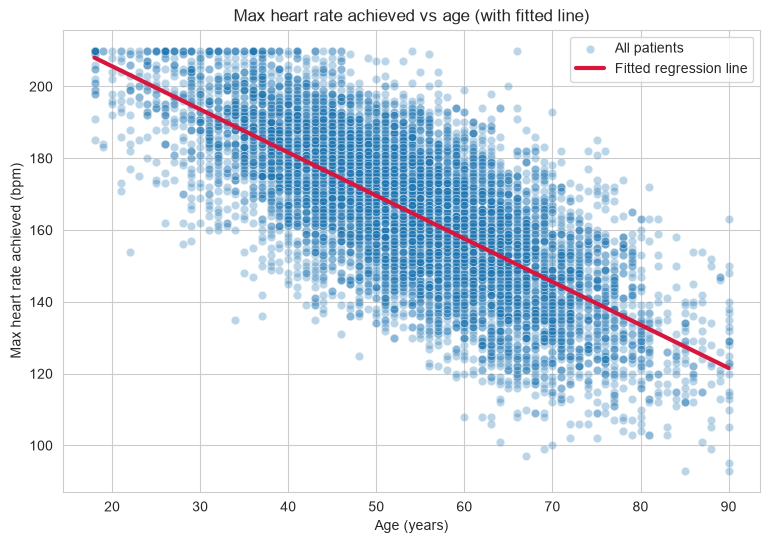

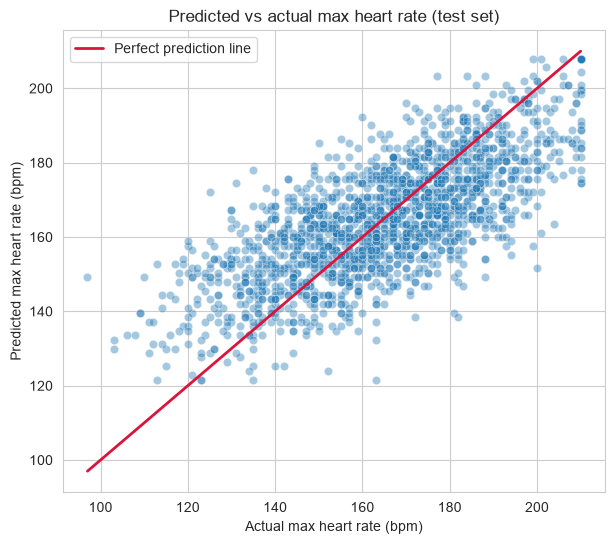

In [5]:
# Plot 1: the data with the fitted regression line
plt.figure(figsize=(9, 6))
sns.scatterplot(x=df["age"], y=df["max_heart_rate_achieved"], alpha=0.3, label="All patients")
age_line = np.linspace(df["age"].min(), df["age"].max(), 100)
hr_line = lin_reg.predict(age_line.reshape(-1, 1))
plt.plot(age_line, hr_line, color="crimson", linewidth=3, label="Fitted regression line")
plt.title("Max heart rate achieved vs age (with fitted line)")
plt.xlabel("Age (years)")
plt.ylabel("Max heart rate achieved (bpm)")
plt.legend()
plt.show()

# Plot 2: predicted vs actual on the TEST set (a good fit hugs the diagonal)
plt.figure(figsize=(7, 6))
sns.scatterplot(x=hr_test, y=hr_pred, alpha=0.4)
plt.plot([hr_test.min(), hr_test.max()], [hr_test.min(), hr_test.max()],
         color="crimson", linewidth=2, label="Perfect prediction line")
plt.title("Predicted vs actual max heart rate (test set)")
plt.xlabel("Actual max heart rate (bpm)")
plt.ylabel("Predicted max heart rate (bpm)")
plt.legend()
plt.show()

### Reading the simple linear regression results

- Fitted line: `max_heart_rate = 229.64 - 1.20 * age`. Each extra year of age lowers the predicted max
  heart rate by about **1.2 bpm** on average, which matches the medical rule of thumb.
- MSE = 216.43, RMSE = 14.71: on the testing set our predictions are off by about **14.7 bpm** on
  average. Heart rate also depends on fitness, medication and other things not in the dataset, so a
  single-feature model cannot be exact. An average error of ~15 bpm seems reasonable for that.
- R-squared = 0.52: age alone explains about **52%** of the variation in max heart rate. Strong for
  one feature, and it confirms the relationship we saw in Part 1 (r = -0.73).

### Improving the model: multiple linear regression

To try to reduce the error, we add a few more clinical features that could affect heart rate: `bmi`,
`resting_bp_systolic`, `hba1c`, `resting_heart_rate` and `sex`. Same Linear Regression technique, just
with more than one predictor. The X table we built already contains the `sex_Male` dummy column.

In [6]:
mlr_cols = ["age", "bmi", "resting_bp_systolic", "hba1c", "resting_heart_rate", "sex_Male"]
X_mlr = X[mlr_cols]

X_mlr_train, X_mlr_test, hr_train2, hr_test2 = train_test_split(
    X_mlr, df["max_heart_rate_achieved"], test_size=0.2, random_state=42
)

mlr = LinearRegression()
mlr.fit(X_mlr_train, hr_train2)
hr_pred2 = mlr.predict(X_mlr_test)

mse2 = mean_squared_error(hr_test2, hr_pred2)
rmse2 = np.sqrt(mse2)
r2_2 = r2_score(hr_test2, hr_pred2)

print("Coefficients (change in max heart rate per unit of each feature):")
for col, coef in zip(mlr_cols, mlr.coef_):
    print("  %-22s %8.3f" % (col, coef))
print("Intercept: %.2f" % mlr.intercept_)
print()
print("Testing set:  MSE = %.2f  |  RMSE = %.2f  |  R-squared = %.3f" % (mse2, rmse2, r2_2))

Coefficients (change in max heart rate per unit of each feature):
  age                      -1.144
  bmi                      -0.287
  resting_bp_systolic      -0.074
  hba1c                    -1.769
  resting_heart_rate       -0.163
  sex_Male                 -2.425
Intercept: 268.09

Testing set:  MSE = 207.17  |  RMSE = 14.39  |  R-squared = 0.545


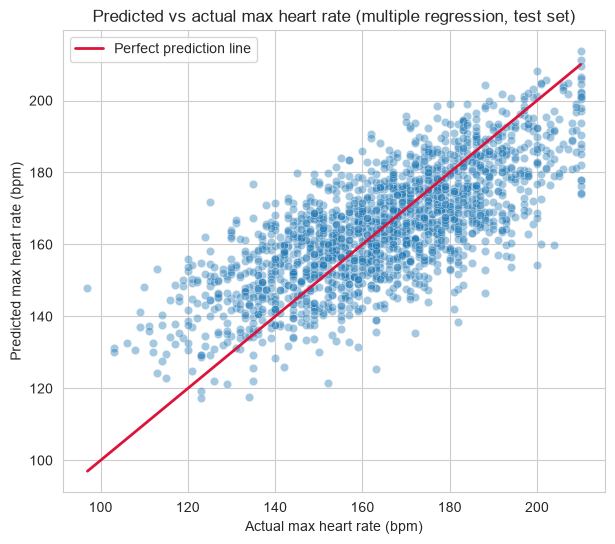

In [7]:
# Predicted vs actual for the multiple regression model
plt.figure(figsize=(7, 6))
sns.scatterplot(x=hr_test2, y=hr_pred2, alpha=0.4)
plt.plot([hr_test2.min(), hr_test2.max()], [hr_test2.min(), hr_test2.max()],
         color="crimson", linewidth=2, label="Perfect prediction line")
plt.title("Predicted vs actual max heart rate (multiple regression, test set)")
plt.xlabel("Actual max heart rate (bpm)")
plt.ylabel("Predicted max heart rate (bpm)")
plt.legend()
plt.show()

### Reading the multiple linear regression results

| Model | MSE | RMSE | R-squared |
|---|---|---|---|
| Simple (age only) | 216.43 | 14.71 | 0.524 |
| Multiple (6 features) | 207.17 | 14.39 | 0.545 |

Adding the 6 features only helped a little: RMSE went from 14.71 to 14.39 and R-squared from 0.52 to
0.55. Looking at the coefficients, **age is doing most of the work** (-1.14) and the rest are small.
So more features is not automatically better; one strong predictor was already carrying the pattern.

### What if we use all the features?

The regression above used only 6 features, but we already have a full feature table `X` with all 19
numerical features plus the dummy columns (the same set used for the classification models). There is
no reason to leave useful features out, so we now fit the regression using **everything**. This shows
whether the features we skipped earlier (smoking, exercise, ST depression, cholesterol, and so on)
carry any extra information about max heart rate.

In [8]:
# IMPORTANT: max_heart_rate_achieved is the target of this regression, so it
# must NOT be one of the features. We drop it from the feature table first.
X_hr = X.drop(columns=["max_heart_rate_achieved"])
y_hr = df["max_heart_rate_achieved"]

print("Regression feature table:", X_hr.shape[1], "features (max_heart_rate_achieved removed)")

X_all_train, X_all_test, y_hr_train, y_hr_test = train_test_split(
    X_hr, y_hr, test_size=0.2, random_state=42
)

mlr_all = LinearRegression()
mlr_all.fit(X_all_train, y_hr_train)
hr_pred_all = mlr_all.predict(X_all_test)

mse_all = mean_squared_error(y_hr_test, hr_pred_all)
rmse_all = np.sqrt(mse_all)
r2_all = r2_score(y_hr_test, hr_pred_all)

print("All-features regression on the testing set:")
print("  MSE = %.2f  |  RMSE = %.2f  |  R-squared = %.3f" % (mse_all, rmse_all, r2_all))
print()
print("Largest coefficients (features that matter most):")
coefs = pd.Series(mlr_all.coef_, index=X_hr.columns)
top = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(8)
for name, value in top.items():
    print("  %-28s %8.3f" % (name, value))
print()
print("Smallest coefficients (features with almost no effect):")
bottom = coefs.reindex(coefs.abs().sort_values().index).head(6)
for name, value in bottom.items():
    print("  %-28s %8.3f" % (name, value))

Regression feature table: 27 features (max_heart_rate_achieved removed)
All-features regression on the testing set:
  MSE = 185.02  |  RMSE = 13.60  |  R-squared = 0.593

Largest coefficients (features that matter most):
  exercise_induced_angina        -5.397
  chest_pain_type_Typical Angina   -3.375
  smoker_status_Never             2.054
  st_depression                  -1.811
  sex_Male                       -1.505
  chest_pain_type_Atypical Angina   -1.404
  family_history                 -1.210
  smoker_status_Former            1.145

Smallest coefficients (features with almost no effect):
  daily_steps                     0.000
  resting_bp_diastolic           -0.003
  fasting_blood_sugar            -0.006
  triglycerides                  -0.009
  alcohol_units_per_week          0.021
  cholesterol_total               0.023


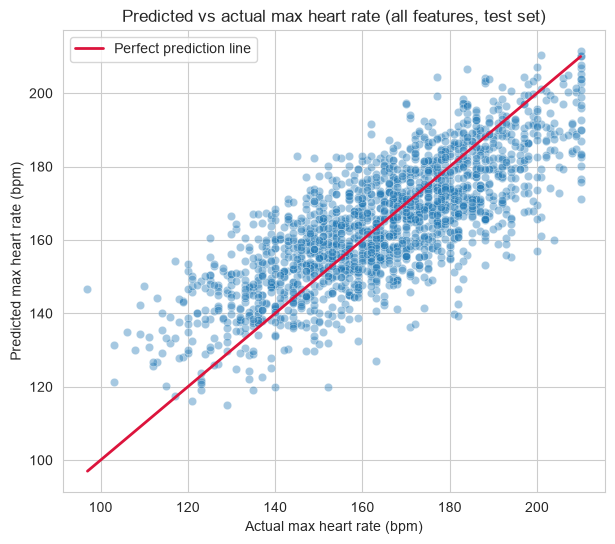

In [9]:
# Predicted vs actual for the all-features model
plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_hr_test, y=hr_pred_all, alpha=0.4)
plt.plot([y_hr_test.min(), y_hr_test.max()], [y_hr_test.min(), y_hr_test.max()],
         color="crimson", linewidth=2, label="Perfect prediction line")
plt.title("Predicted vs actual max heart rate (all features, test set)")
plt.xlabel("Actual max heart rate (bpm)")
plt.ylabel("Predicted max heart rate (bpm)")
plt.legend()
plt.show()

### Reading the all-features regression results

| Model | MSE | RMSE | R-squared |
|---|---|---|---|
| Simple (age only) | 216.43 | 14.71 | 0.524 |
| Multiple (6 features) | 207.17 | 14.39 | 0.545 |
| Multiple (all features) | 185.02 | 13.60 | 0.594 |

Using all the features **did** help: RMSE fell from 14.39 to 13.60 and R-squared rose from 0.55 to
0.59. So the features we skipped in the 6-feature model were not useless.

Looking at the largest coefficients, the features that carry the most information are:

- `exercise_induced_angina` (-5.40): patients who get chest pain during exercise reach a clearly lower
  max heart rate. Makes sense: the pain stops them from pushing as hard.
- `chest_pain_type_Typical Angina` (-3.38): typical angina is also linked to a lower max heart rate.
- `smoker_status_Never` (+2.05): never-smokers reach a somewhat higher max heart rate than the baseline.
- `st_depression` (-1.81), `sex_Male` (-1.51) and `age` (-1.08): more ST depression, being male and
  older age all lower max heart rate.

The features with coefficients very close to zero (daily steps, triglycerides, fasting blood sugar,
alcohol, cholesterol, resting blood pressure) contribute almost nothing once the other features are in
the model. So the extra features from the earlier question (exercise, ST depression, smoking, chest
pain) turn out to matter, while alcohol and step count barely matter for max heart rate.

## 2.3 Logistic Regression (classification task)

### Choosing the target and the features

The assignment asks for a classification task. We predict:

- **Target:** `has_heart_disease` (1 = disease, 0 = no disease). A binary categorical target, exactly
  what logistic regression is designed for.
- **Features:** all the numerical features and the encoded categorical columns together. Logistic
  regression combines them into a single **probability** between 0 and 1 for each patient.

Part 1 showed that several features separate the two groups clearly (low max heart rate, high ST
depression, older age, worse cholesterol, higher blood pressure), so a logistic model should work well.

Because the target is imbalanced (only 30.3% have disease), plain accuracy can be misleading: a model
that always predicts "no disease" would already be ~70% correct. So besides accuracy we report the
**F1 score**, which balances precision and recall and is the better measure here. We also show the
confusion matrix and the ROC-AUC.

In [10]:
# logistic regression and kNN are sensitive to feature scale, so we
# standardise everything (mean 0, std 1) before fitting.
scaler = StandardScaler()
scaler.fit(X_train)                   # learn the scaling from the TRAINING set only
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)  # apply the same scaling to the TEST set

print("Scaling done: every feature now has mean ~0 and standard deviation ~1.")
print("Training set size:", X_train_s.shape, "| Testing set size:", X_test_s.shape)

Scaling done: every feature now has mean ~0 and standard deviation ~1.
Training set size: (7200, 28) | Testing set size: (1800, 28)


In [11]:
log_reg = LogisticRegression(max_iter=2000, random_state=42)
log_reg.fit(X_train_s, y_train)

y_pred = log_reg.predict(X_test_s)
y_prob = log_reg.predict_proba(X_test_s)[:, 1]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob)

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix (rows = actual, columns = predicted):")
print("                 predicted:  no disease    disease")
print("  actual no disease             %5d     %5d" % (cm[0, 0], cm[0, 1]))
print("  actual disease                %5d     %5d" % (cm[1, 0], cm[1, 1]))
print()
print("Accuracy  = %.4f" % acc)
print("Precision = %.4f" % prec)
print("Recall    = %.4f" % rec)
print("F1 score  = %.4f" % f1)
print("ROC-AUC   = %.4f" % auc)

Confusion matrix (rows = actual, columns = predicted):
                 predicted:  no disease    disease
  actual no disease              1186        69
  actual disease                  116       429

Accuracy  = 0.8972
Precision = 0.8614
Recall    = 0.7872
F1 score  = 0.8226
ROC-AUC   = 0.9497


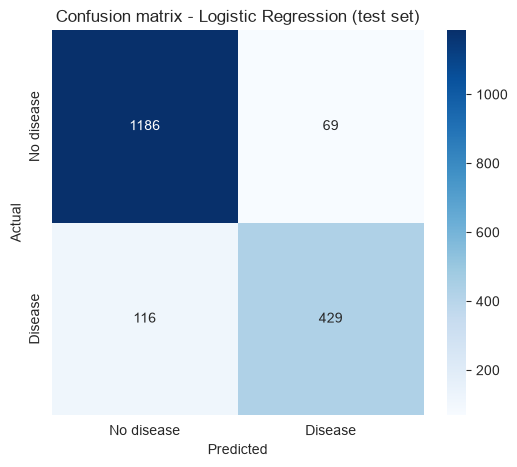

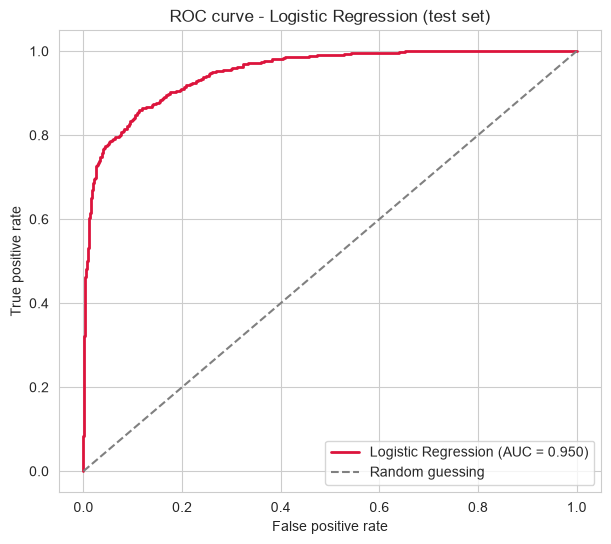

In [12]:
# confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No disease", "Disease"],
            yticklabels=["No disease", "Disease"])
plt.title("Confusion matrix - Logistic Regression (test set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC curve (trade-off between true and false positive rate)
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="crimson", linewidth=2, label="Logistic Regression (AUC = %.3f)" % auc)
plt.plot([0, 1], [0, 1], color="grey", linestyle="--", label="Random guessing")
plt.title("ROC curve - Logistic Regression (test set)")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend()
plt.show()

### Reading the logistic regression results

- Accuracy = 0.897 (about 90% of test patients were classified correctly). This looks high, but
  remember the target is imbalanced: a naive model that always says "no disease" would already reach
  ~70% accuracy. Accuracy alone is not enough.
- F1 score = 0.823 is the better measure here. It balances:
  - Precision = 0.861: when the model says "disease", it is correct about 86% of the time.
  - Recall = 0.787: the model catches about 79% of the patients who actually have disease.
- Confusion matrix: of the 1800 test patients, the model found 429 of the 545 real disease patients
  (116 missed, false negatives) and wrongly flagged only 69 healthy patients (false positives). In
  medicine, missing a disease patient (a false negative) is the more dangerous error, so the fairly
  high recall is reassuring.
- ROC-AUC = 0.950: the model ranks a random disease patient higher than a random healthy patient about
  95% of the time. The two groups are clearly well separated.

This lines up with what we saw in Part 1: the features separate the two groups very well.

## 2.4 Additional Models (optional section)

To explore further, we try four more classification models and compare them with Logistic Regression.
The models:

- **k-Nearest Neighbors (kNN):** classifies a patient by looking at the 5 closest training patients.
- **Decision Tree:** splits patients with simple if-then rules (we limit depth to 5 to avoid overfitting).
- **Random Forest:** builds many decision trees and averages their votes; usually more accurate.
- **Naive Bayes:** a simple probabilistic model using Bayes rule (assumes features are independent).

All models get the same scaled training and testing sets, so the comparison is fair. We compare
accuracy, precision, recall and F1 score.

In [13]:
extra_models = {
    "kNN":           KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Naive Bayes":   GaussianNB(),
}

rows = []
for name, model in extra_models.items():
    model.fit(X_train_s, y_train)
    pred = model.predict(X_test_s)
    rows.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred),
    ])

# logistic regression row added for comparison
rows.append(["Logistic Regression", acc, prec, rec, f1])

comparison = pd.DataFrame(rows, columns=["Model", "Accuracy", "Precision", "Recall", "F1 score"])
comparison = comparison.round(4)
comparison

,Model,Accuracy,Precision,Recall,F1 score
0,kNN,0.8550,0.8604,0.6220,0.7220
1,Decision Tree,0.8544,0.8004,0.6917,0.7421
2,Random Forest,0.8806,0.8526,0.7321,0.7878
3,Naive Bayes,0.8700,0.7686,0.8165,0.7918
4,Logistic Regression,0.8972,0.8614,0.7872,0.8226


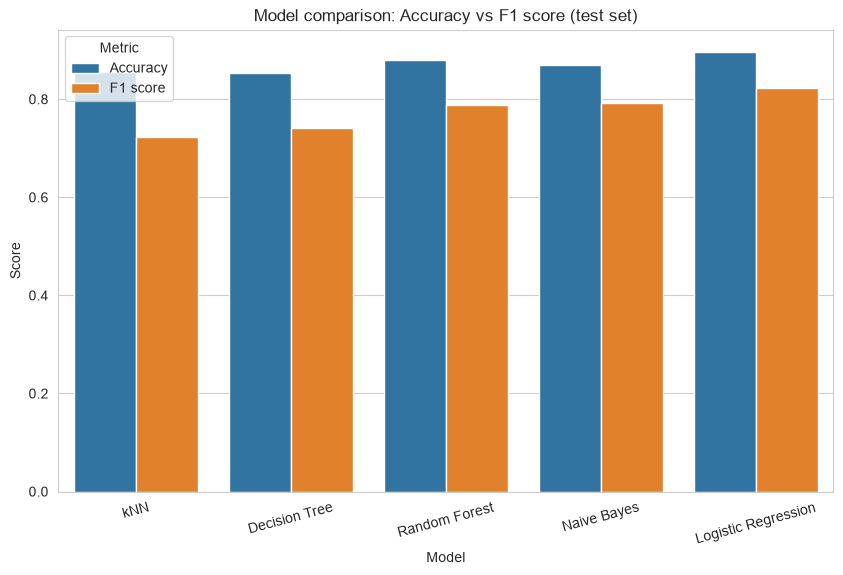

In [14]:
# bar chart comparing Accuracy and F1 score across all five models
comparison_plot = comparison.melt(id_vars="Model", value_vars=["Accuracy", "F1 score"],
                                  var_name="Metric", value_name="Value")
plt.figure(figsize=(10, 6))
sns.barplot(data=comparison_plot, x="Model", y="Value", hue="Metric")
plt.title("Model comparison: Accuracy vs F1 score (test set)")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.legend(title="Metric")
plt.show()

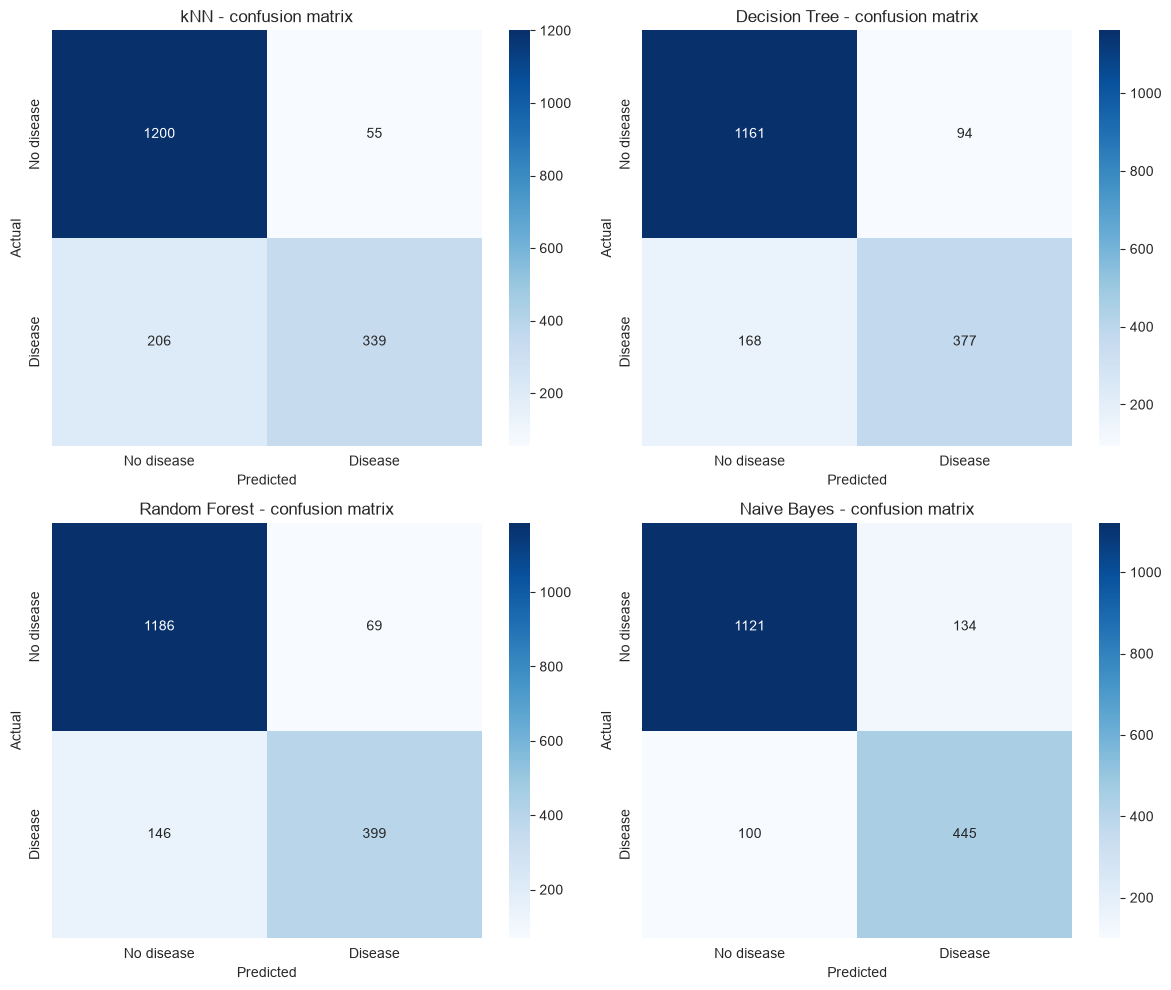

In [15]:
# confusion matrices of the four additional models, side by side
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (name, model) in zip(axes.flat, extra_models.items()):
    pred = model.predict(X_test_s)
    cm_m = confusion_matrix(y_test, pred)
    sns.heatmap(cm_m, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No disease", "Disease"],
                yticklabels=["No disease", "Disease"])
    ax.set_title("%s - confusion matrix" % name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

### Reading the additional model results

| Model | Accuracy | Precision | Recall | F1 score |
|---|---|---|---|---|
| Logistic Regression | 0.897 | 0.861 | 0.787 | 0.823 |
| Random Forest | 0.881 | 0.853 | 0.732 | 0.788 |
| Naive Bayes | 0.870 | 0.769 | 0.817 | 0.792 |
| kNN | 0.855 | 0.860 | 0.622 | 0.722 |
| Decision Tree | 0.854 | 0.800 | 0.692 | 0.742 |

- Logistic Regression is the best overall on F1 (0.823) and accuracy (0.897). This makes sense: the
  data is "linear friendly" (the features separate the groups smoothly, as the AUC of 0.95 showed), so
  the simple linear model beats the more complex ones.
- Random Forest comes second (F1 0.788). It is more flexible, but here the extra flexibility does not
  help much and trees can overfit the training noise.
- Naive Bayes has the highest recall (0.817): it is aggressive at calling disease, so it misses fewer
  real patients, but at the cost of lower precision (0.769), meaning more healthy patients are wrongly
  flagged.
- kNN and the Decision Tree are the weakest. kNN suffers because the "no disease" group dominates its
  nearest neighbours, and a depth-5 tree is too simple for this data.

## 2.5 Results and Discussion

### What the results indicate

The models agree with the Part 1 findings: heart disease in this dataset is very
predictable. Logistic regression reaches ROC-AUC = 0.95 and F1 = 0.82, which is strong for a healthcare
classification task. The regression model also behaved as we would expect: age explains about 52% of
the variation in max heart rate, and the fitted slope (about -1.2 bpm per year) matches the medical
rule of thumb.

### Is the performance good or poor, and why

The performance is good, mainly because the dataset is clean and the features are informative:

- No missing values, no duplicates and no impossible values (Part 1), so the models were never
  disturbed by dirty input.
- The strongest predictors (`max_heart_rate_achieved`, `st_depression`, `age`, cholesterol fractions,
  blood pressure) separate the two groups clearly, which is why the AUC is so high.
- The target imbalance (30.3% positive) did not hurt much here because the signal is strong. It still
  matters for evaluation, which is why we relied on F1 and ROC-AUC rather than accuracy alone.

### Limitations and issues

- Class imbalance: a naive model that always predicts "no disease" would already reach ~70% accuracy.
  This is why we never judged the models by accuracy alone; F1 and AUC are more reliable here.
- Synthetic data: the dataset is artificially generated (Kaggle, "Heart Disease Risk 2026"). Real
  clinical data is noisier, so these exact numbers would likely not transfer to real patients.
- The regression is approximate: it predicts max heart rate with an RMSE of about 14 bpm. Heart rate
  also depends on fitness, medication and other factors not in the dataset.
- False negatives: in medicine, missing a real heart-disease patient is the most dangerous error. Our
  logistic model still misses about 21% of disease patients (116 of 545 in the test set). A
  higher-recall model (like Naive Bayes) catches more, but at the price of more false alarms.

### How the dataset characteristics affected the results

The clean, well-separated data is the main reason all models performed well. Because the classes are
nearly linearly separable (AUC 0.95 for logistic regression), the simplest model wins; complex models
such as Random Forest or kNN never get a chance to show an advantage. If the data were noisier or more
overlapping, the tree-based models might catch up.

## 2.6 Conclusions

1. Linear Regression modelled the relationship between age and max heart rate (RMSE ~14.7 bpm,
   R-squared ~0.52 for age alone). The fitted slope agrees with the medical rule that max heart rate
   falls by about 1.2 bpm per year of age.
2. Logistic Regression classified patients into disease / no disease with accuracy 0.897, F1 0.823 and
   ROC-AUC 0.950. Given the 30.3% positive rate, these are strong and trustworthy numbers.
3. The extra models (kNN, Decision Tree, Random Forest, Naive Bayes) confirmed that Logistic
   Regression is the best choice for this dataset. None of them beat it on F1 or accuracy.
4. The modelling confirms the Part 1 clinical story: low max heart rate, high ST depression, older age,
   worse cholesterol and higher blood pressure are the features that predict heart disease.
5. The main caveat is class imbalance: always evaluate with F1 and ROC-AUC, never with accuracy alone,
   and keep in mind the dataset is synthetic.

The two mandatory models are complete, compared and discussed. This notebook is the modelling part
(Part 2) of the project; it will be combined with the Part 1 exploratory notebook into the final report.